<a href="https://colab.research.google.com/github/nivethithanm/torchcode-solutions/blob/main/TC_24a_rope_from_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MASTER-01: RoPE Embeddings — From Circles to Transformers

**Time**: ~4 hours | **Goal**: Build RoPE from scratch, understanding EVERY step

**The problem this solves**: Attention is position-blind. `q·k` gives the same score whether two tokens are adjacent or 1000 positions apart. We need a way to make attention aware of position WITHOUT adding separate position embeddings.

**What you'll build through 7 progressive stages**:
1. 2D rotation (plain trigonometry)
2. Why rotation encodes position
3. How rotation makes dot products position-aware
4. Extending to high dimensions (pair-wise rotation)
5. The frequency spectrum (why different pairs rotate at different speeds)
6. Full RoPE implementation
7. Connection to the actual TorchCode notebook

**No jumping ahead. Each stage unlocks the next.**

In [ ]:
import torch
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Stage 1: Rotating a Point in 2D (~15 min)

Before we touch transformers, let's get rotation right.

A 2D rotation by angle θ transforms point (x, y) to:
```
x' = x·cos(θ) - y·sin(θ)
y' = x·sin(θ) + y·cos(θ)
```

As a matrix:
```
┌ x' ┐   ┌ cos(θ)  -sin(θ) ┐ ┌ x ┐
│    │ = │                   │ │   │
└ y' ┘   └ sin(θ)   cos(θ)  ┘ └ y ┘
```

That's it. That's the entire foundation of RoPE.

In [ ]:
# Exercise 1.1: Implement 2D rotation

def rotate_2d(point: torch.Tensor, theta: float) -> torch.Tensor:
    """Rotate a 2D point by angle theta (in radians).

    Args:
        point: shape (2,) — [x, y]
        theta: rotation angle in radians
    Returns:
        rotated point, shape (2,)
    """
    # YOUR CODE HERE
    rotation_matrix = torch.tensor([
        [math.cos(theta), -math.sin(theta)],
        [math.sin(theta), math.cos(theta)]
    ])
    return rotation_matrix @ point

# Test: rotate (1, 0) by 90° → should give (0, 1)
p = torch.tensor([1.0, 0.0])
rotated = rotate_2d(p, math.pi / 2)
assert torch.allclose(rotated, torch.tensor([0.0, 1.0]), atol=1e-6), f'Got {rotated}'

# Test: rotate (1, 0) by 180° → should give (-1, 0)
rotated = rotate_2d(p, math.pi)
assert torch.allclose(rotated, torch.tensor([-1.0, 0.0]), atol=1e-6)

# Test: rotate (1, 0) by 360° → back to (1, 0)
rotated = rotate_2d(p, 2 * math.pi)
assert torch.allclose(rotated, torch.tensor([1.0, 0.0]), atol=1e-5)

print('✅ Stage 1.1: 2D rotation works')

✅ Stage 1.1: 2D rotation works


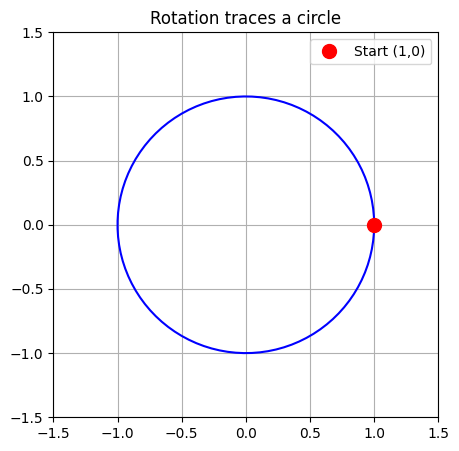

Rotation = moving along a circle. The angle = how far along.


In [ ]:
# Exercise 1.2: Visualize rotation
# Rotate the point (1, 0) by angles 0° to 360° and plot the trajectory

angles = torch.linspace(0, 2 * math.pi, 100)
points = torch.stack([rotate_2d(torch.tensor([1.0, 0.0]), a.item()) for a in angles])

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(points[:, 0], points[:, 1], 'b-')
ax.plot(1, 0, 'ro', markersize=10, label='Start (1,0)')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.grid(True); ax.legend()
ax.set_title('Rotation traces a circle')
plt.show()
print('Rotation = moving along a circle. The angle = how far along.')

In [ ]:
# Exercise 1.3: KEY PROPERTY — rotation preserves length!
# This is critical for RoPE: rotating q and k doesn't change their magnitudes

p = torch.tensor([3.0, 4.0])  # length = 5
for theta in [0.1, 0.5, 1.0, 2.0, 5.0]:
    r = rotate_2d(p, theta)
    # YOUR TASK: verify that the length is preserved
    original_length = torch.norm(p)
    rotated_length = torch.norm(r)
    assert torch.allclose(original_length, rotated_length, atol=1e-5)

print('✅ Stage 1.3: Rotation preserves vector length')
print('This means rotating q and k won\'t distort their magnitudes.')
print('Only the ANGLE between them changes — which is exactly what we want.')

✅ Stage 1.3: Rotation preserves vector length
This means rotating q and k won't distort their magnitudes.
Only the ANGLE between them changes — which is exactly what we want.


## Stage 2: Why Rotation Encodes Position (~20 min)

**The key idea**: Assign each position a rotation angle. Position 0 = no rotation. Position m = rotate by m·θ.

If we rotate a vector by different amounts at different positions, the vector at position 5 looks different from the same vector at position 10. The attention mechanism can then distinguish them.

In [ ]:
# Exercise 2.1: Position-dependent rotation

def apply_position_rotation(vec: torch.Tensor, position: int,
                            base_angle: float = 0.1) -> torch.Tensor:
    """Rotate a 2D vector by position * base_angle.

    Position 0 → no rotation
    Position 1 → rotate by base_angle
    Position m → rotate by m * base_angle
    """
    # YOUR CODE HERE
    rotation_matrix = torch.tensor([
        [math.cos(position*base_angle), -math.sin(position*base_angle)],
        [math.sin(position*base_angle), math.cos(position*base_angle)]
    ])
    return rotation_matrix @ vec

# Take the same vector, apply at different positions
vec = torch.tensor([1.0, 0.5])
for pos in [0, 5, 10, 20]:
    rotated = apply_position_rotation(vec, pos)
    print(f'  Position {pos:2d}: [{rotated[0]:.3f}, {rotated[1]:.3f}], Norm: {torch.norm(rotated)}')

print('\nSame vector, different positions → different representations.')
print('The attention mechanism can now tell positions apart!')

  Position  0: [1.000, 0.500], Norm: 1.1180340051651
  Position  5: [0.638, 0.918], Norm: 1.1180340051651
  Position 10: [0.120, 1.112], Norm: 1.1180338859558105
  Position 20: [-0.871, 0.701], Norm: 1.1180338859558105

Same vector, different positions → different representations.
The attention mechanism can now tell positions apart!


In [ ]:
# Exercise 2.2: THE MAGIC — dot product of rotated vectors depends on RELATIVE position

def dot_product_at_positions(vec_q: torch.Tensor, vec_k: torch.Tensor,
                              pos_q: int, pos_k: int,
                              base_angle: float = 0.1) -> float:
    """Compute dot product of q at pos_q and k at pos_k."""
    q_rotated = apply_position_rotation(vec_q, pos_q, base_angle)
    k_rotated = apply_position_rotation(vec_k, pos_k, base_angle)
    return torch.dot(q_rotated, k_rotated).item()

# THE CRITICAL TEST: dot product depends only on (pos_q - pos_k), NOT absolute positions!
vec_q = torch.tensor([1.0, 0.5])
vec_k = torch.tensor([0.8, 0.3])

# These all have the same relative distance (5):
pairs = [(0, 5), (3, 8), (10, 15), (100, 105), (10000, 10005)]
dots = [dot_product_at_positions(vec_q, vec_k, pq, pk) for pq, pk in pairs]

print('Dot products for relative distance = 5:')
for (pq, pk), d in zip(pairs, dots):
    print(f'  q@{pq}, k@{pk}: {d:.8f}')

# All should be (approximately) equal!
assert all(abs(d - dots[0]) < 1e-5 for d in dots), 'Not all equal!'
print(f'\n✅ ALL EQUAL! Dot product depends only on relative position.')
print('This is the ENTIRE point of RoPE.')
print('It encodes RELATIVE position into the attention score.')

Dot products for relative distance = 5:
  q@0, k@5: 0.88164604
  q@3, k@8: 0.88164604
  q@10, k@15: 0.88164598
  q@100, k@105: 0.88164604
  q@10000, k@10005: 0.88164598

✅ ALL EQUAL! Dot product depends only on relative position.
This is the ENTIRE point of RoPE.
It encodes RELATIVE position into the attention score.


In [ ]:
# Exercise 2.3: PROVE it mathematically (implement the proof)

# If q is rotated by m*θ and k by n*θ, then:
# q_rot · k_rot = q^T · R(m*θ)^T · R(n*θ) · k
#               = q^T · R((n-m)*θ) · k
#               = q^T · R(relative_pos * θ) · k
#
# Because R(a)^T · R(b) = R(b-a)  (rotation matrices compose by adding angles)

# YOUR TASK: Verify this numerically
m, n = 7, 12
theta = 0.1

q = torch.tensor([1.0, 0.5])
k = torch.tensor([0.8, 0.3])

# Method 1: Rotate separately, dot product
q_rot = rotate_2d(q, m * theta)
k_rot = rotate_2d(k, n * theta)
dot_method1 = torch.dot(q_rot, k_rot)

# Method 2: Rotate k by (n-m)*theta relative to q (no rotation on q)
k_relative = rotate_2d(k, (n - m) * theta)
dot_method2 = torch.dot(q, k_relative)

assert torch.allclose(dot_method1, dot_method2, atol=1e-5)
print(f'Method 1 (rotate both):     {dot_method1:.6f}')
print(f'Method 2 (relative only):   {dot_method2:.6f}')
print(f'\n✅ Stage 2.3: Proven — RoPE encodes RELATIVE position.')

Method 1 (rotate both):     0.881646
Method 2 (relative only):   0.881646

✅ Stage 2.3: Proven — RoPE encodes RELATIVE position.


## Stage 3: High Dimensions — Pair-wise Rotation (~25 min)

Real embeddings have d=64 or d=128 dimensions, not 2.

**RoPE's trick**: Take the d-dimensional vector and split it into d/2 PAIRS. Rotate each pair independently, at a DIFFERENT speed.

```
d=8 vector: [x0, x1, x2, x3, x4, x5, x6, x7]
                ↓       ↓       ↓       ↓
           pair 0   pair 1   pair 2   pair 3
          (x0,x1)  (x2,x3)  (x4,x5)  (x6,x7)
             ↓       ↓       ↓       ↓
         rotate    rotate   rotate   rotate
         by θ₀     by θ₁    by θ₂    by θ₃
```
Each pair uses a DIFFERENT base frequency. This gives the model rich positional information.

In [ ]:
# Exercise 3.1: Rotate d-dimensional vector by pairs

def rotate_pairs(vec: torch.Tensor, thetas: torch.Tensor) -> torch.Tensor:
    """Rotate a d-dimensional vector by applying 2D rotation to each consecutive pair.

    Args:
        vec: shape (d,) where d is even
        thetas: shape (d//2,) — one rotation angle per pair
    Returns:
        rotated vector, shape (d,)

    Pair i: (vec[2i], vec[2i+1]) rotated by thetas[i]
    """
    d = vec.shape[0]
    assert d % 2 == 0
    result = torch.zeros_like(vec)

    # YOUR CODE HERE
    # For each pair i:
    #   x, y = vec[2*i], vec[2*i+1]
    #   result[2*i]   = x*cos(thetas[i]) - y*sin(thetas[i])
    #   result[2*i+1] = x*sin(thetas[i]) + y*cos(thetas[i])
    x, y = vec[0::2], vec[1::2]
    cos_theta = torch.cos(thetas)
    sin_theta = torch.sin(thetas)
    x_new, y_new = x * cos_theta - y * sin_theta, x * sin_theta + y * cos_theta
    result[0::2], result[1::2] = x_new, y_new
    return result

# Test: d=6, three pairs
vec = torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0, 0.0])
thetas = torch.tensor([math.pi/2, math.pi/4, 0.0])  # 90°, 45°, 0°

rotated = rotate_pairs(vec, thetas)
print(f'Original: {vec}')
print(f'Rotated:  {rotated}')

# Pair 0 rotated 90°: (1,0) → (0,1)
assert torch.allclose(rotated[0:2], torch.tensor([0.0, 1.0]), atol=1e-6)
# Pair 2 rotated 0°: unchanged
assert torch.allclose(rotated[4:6], torch.tensor([1.0, 0.0]), atol=1e-6)

print('✅ Stage 3.1: Pair-wise rotation')

Original: tensor([1., 0., 1., 0., 1., 0.])
Rotated:  tensor([-4.3711e-08,  1.0000e+00,  7.0711e-01,  7.0711e-01,  1.0000e+00,
         0.0000e+00])
✅ Stage 3.1: Pair-wise rotation


In [ ]:
# Exercise 3.2: Verify that pair-wise rotation still preserves the dot product property!

d = 8
torch.manual_seed(42)
q = torch.randn(d)
k = torch.randn(d)

# Use same thetas but scaled by position
base_thetas = torch.tensor([0.1, 0.05, 0.025, 0.0125])  # d//2 = 4 frequencies

def rotate_at_position(vec, pos, base_thetas):
    return rotate_pairs(vec, pos * base_thetas)

# Test: relative position property
pairs = [(0, 5), (10, 15), (50, 55)]  # all have distance 5
dots = []
for pq, pk in pairs:
    q_rot = rotate_at_position(q, pq, base_thetas)
    k_rot = rotate_at_position(k, pk, base_thetas)
    dots.append(torch.dot(q_rot, k_rot).item())
    print(f'  q@{pq}, k@{pk}: dot={dots[-1]:.6f}')

assert all(abs(d - dots[0]) < 1e-4 for d in dots)
print(f'\n✅ Stage 3.2: Relative position property holds in d={d} dimensions!')

  q@0, k@5: dot=-3.631526
  q@10, k@15: dot=-3.631526
  q@50, k@55: dot=-3.631526

✅ Stage 3.2: Relative position property holds in d=8 dimensions!


## Stage 4: The Frequency Spectrum (~20 min)

**Why different pairs rotate at different speeds?**

If all pairs rotated at the same speed, positions 0 and 2π/θ would look identical (wrapped around). Using DIFFERENT frequencies gives each position a unique 'fingerprint'.

The standard RoPE frequencies (from the paper):
```
θᵢ = 1 / (base^(2i/d))   where i = 0, 1, ..., d/2-1
```
Default base = 10000. Pair 0 rotates fast (short-range patterns). Last pair rotates slow (long-range patterns).

In [ ]:
d = 51
theta = torch.arange(d//2)
theta = 1.0 / (10000 ** (2 * theta / d))
# theta = torch.exp(-2 * theta / d)

In [ ]:
theta

tensor([1.0000e+00, 6.9685e-01, 4.8560e-01, 3.3839e-01, 2.3580e-01, 1.6432e-01,
        1.1450e-01, 7.9792e-02, 5.5603e-02, 3.8747e-02, 2.7001e-02, 1.8815e-02,
        1.3111e-02, 9.1366e-03, 6.3668e-03, 4.4367e-03, 3.0917e-03, 2.1544e-03,
        1.5013e-03, 1.0462e-03, 7.2903e-04, 5.0802e-04, 3.5401e-04, 2.4669e-04,
        1.7191e-04])

In [ ]:
# Exercise 4.1: Compute RoPE frequencies

def compute_rope_frequencies(d: int, base: float = 10000.0) -> torch.Tensor:
    """Compute the d//2 base frequencies for RoPE.

    theta_i = 1.0 / (base ** (2*i / d))  for i in [0, d//2)

    Returns: shape (d//2,)
    """
    # YOUR CODE HERE
    theta = torch.arange(d//2)
    theta = 1.0 / (base ** (2 * theta / d))
    return theta

# Test
freqs = compute_rope_frequencies(64)
print(f'First freq (pair 0):  {freqs[0]:.6f}  — fast rotation (captures local patterns)')
print(f'Last freq (pair 31):  {freqs[-1]:.8f}  — slow rotation (captures global patterns)')
print(f'Ratio first/last:     {freqs[0]/freqs[-1]:.0f}x')
assert freqs[0] > freqs[-1]  # first pair rotates faster
assert freqs.shape == (32,)
print('\n✅ Stage 4.1: RoPE frequencies')

First freq (pair 0):  1.000000  — fast rotation (captures local patterns)
Last freq (pair 31):  0.00013335  — slow rotation (captures global patterns)
Ratio first/last:     7499x

✅ Stage 4.1: RoPE frequencies


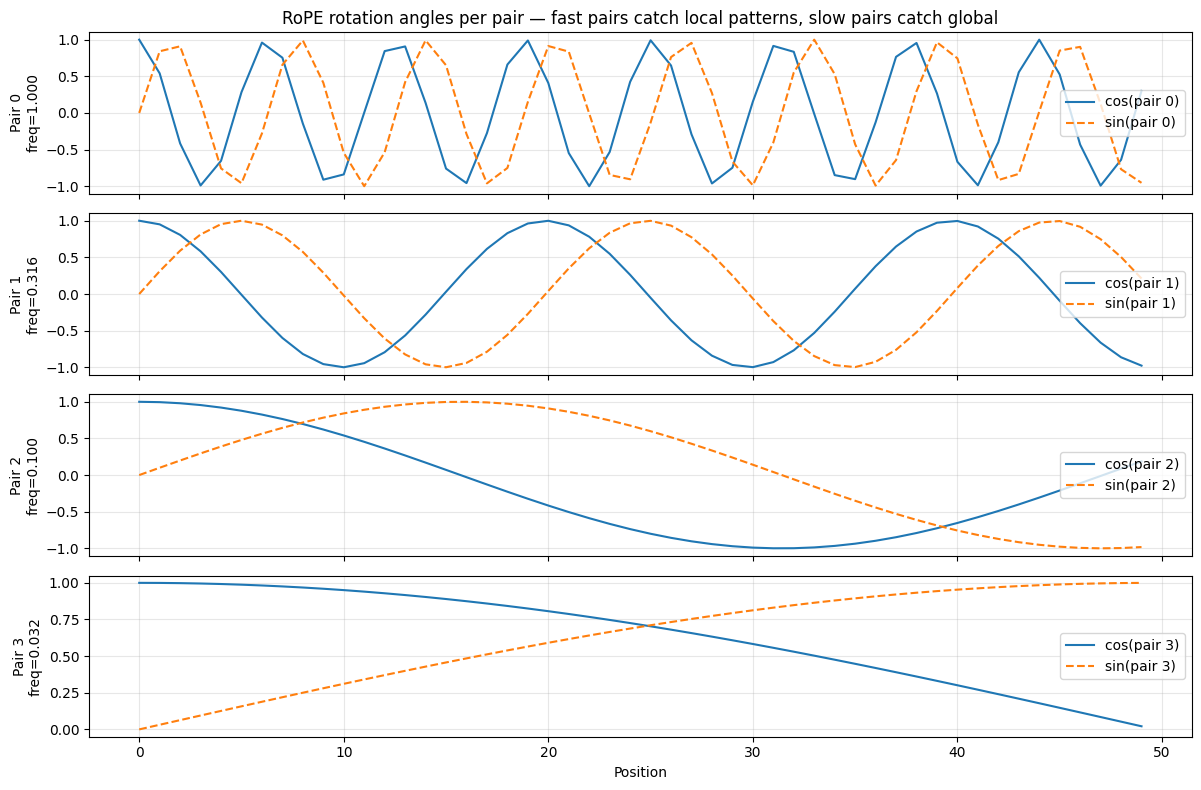

Pair 0: oscillates fast → different for adjacent positions
Pair 3: oscillates slow → different for distant positions
Combined: every position gets a UNIQUE fingerprint!


In [ ]:
# Exercise 4.2: Visualize how different frequencies create unique position fingerprints

d = 8  # small for visualization
freqs = compute_rope_frequencies(d, base=100.0)  # smaller base for visual clarity

fig, axes = plt.subplots(d//2, 1, figsize=(12, 8), sharex=True)
positions = torch.arange(50)

for i in range(d//2):
    angles = positions * freqs[i]
    axes[i].plot(positions.numpy(), torch.cos(angles).numpy(), label=f'cos(pair {i})')
    axes[i].plot(positions.numpy(), torch.sin(angles).numpy(), label=f'sin(pair {i})', linestyle='--')
    axes[i].set_ylabel(f'Pair {i}\nfreq={freqs[i]:.3f}')
    axes[i].legend(loc='right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Position')
axes[0].set_title('RoPE rotation angles per pair — fast pairs catch local patterns, slow pairs catch global')
plt.tight_layout()
plt.show()

print('Pair 0: oscillates fast → different for adjacent positions')
print('Pair 3: oscillates slow → different for distant positions')
print('Combined: every position gets a UNIQUE fingerprint!')

## Stage 5: The Efficient Implementation (~25 min)

The pair-by-pair loop is slow. The production implementation uses an element-wise trick:

Instead of building rotation matrices, we split the vector into first half and second half, then:
```
out[0:d//2]   = x[0:d//2] * cos - x[d//2:d] * sin
out[d//2:d]   = x[0:d//2] * sin + x[d//2:d] * cos
```

This is the SAME rotation, just rearranged for vectorized computation.

In [ ]:
# Exercise 5.1: Show that the rearranged formula is equivalent

d = 8
torch.manual_seed(42)
vec = torch.randn(d)
pos = 7
freqs = compute_rope_frequencies(d)
thetas = pos * freqs  # rotation angles for this position

# Method 1: pair-by-pair (from Stage 3)
result_pairs = rotate_pairs(vec, thetas)

# Method 2: interleaved cos/sin (production formula)
# Rearrange vec as pairs: (x0,x1), (x2,x3), ...
# x_even = vec[0::2], x_odd = vec[1::2]
x_even = vec[0::2]  # x0, x2, x4, x6
x_odd = vec[1::2]   # x1, x3, x5, x7

cos_theta = torch.cos(thetas)
sin_theta = torch.sin(thetas)

result_vectorized = torch.zeros_like(vec)
result_vectorized[0::2] = x_even * cos_theta - x_odd * sin_theta
result_vectorized[1::2] = x_even * sin_theta + x_odd * cos_theta

assert torch.allclose(result_pairs, result_vectorized, atol=1e-6)
print(f'Pair-by-pair:  {result_pairs}')
print(f'Vectorized:    {result_vectorized}')
print(f'Match: ✅')
print(f'\nThe vectorized version does the same thing — no loop over pairs!')

Pair-by-pair:  tensor([ 0.1692,  0.3183,  0.0309,  0.3272, -1.1071, -0.2644,  2.2126, -0.6225])
Vectorized:    tensor([ 0.1692,  0.3183,  0.0309,  0.3272, -1.1071, -0.2644,  2.2126, -0.6225])
Match: ✅

The vectorized version does the same thing — no loop over pairs!


In [ ]:
# Exercise 5.2: Precompute the cos/sin table for all positions

def precompute_rope_cache(max_seq_len: int, d: int, base: float = 10000.0):
    """Precompute cos and sin values for all positions.

    Returns:
        cos_cache: shape (max_seq_len, d//2)
        sin_cache: shape (max_seq_len, d//2)

    cos_cache[pos, i] = cos(pos * freq_i)
    sin_cache[pos, i] = sin(pos * freq_i)
    """
    # YOUR CODE HERE
    # 1. Compute frequencies: shape (d//2,)
    # 2. Compute positions: shape (max_seq_len, 1)
    # 3. Outer product: positions × frequencies → shape (max_seq_len, d//2)
    # 4. Take cos and sin
    positions = torch.arange(max_seq_len, dtype=torch.float32)
    frequencies = compute_rope_frequencies(d, base)
    outer_product = torch.outer(positions, frequencies)
    cos_cache = torch.cos(outer_product)
    sin_cache = torch.sin(outer_product)
    return cos_cache, sin_cache


cos_cache, sin_cache = precompute_rope_cache(1024, 64)
assert cos_cache.shape == (1024, 32)
assert sin_cache.shape == (1024, 32)

# Verify: cos_cache[0, :] should be all 1s (cos(0) = 1)
assert torch.allclose(cos_cache[0], torch.ones(32))
# sin_cache[0, :] should be all 0s (sin(0) = 0)
assert torch.allclose(sin_cache[0], torch.zeros(32), atol=1e-7)

print('✅ Stage 5.2: Precomputed cos/sin cache')

✅ Stage 5.2: Precomputed cos/sin cache


## Stage 6: Full RoPE — Apply to Query and Key Tensors (~25 min)

In [42]:
def apply_rope(x: torch.Tensor, cos_cache: torch.Tensor,
               sin_cache: torch.Tensor) -> torch.Tensor:
    """Apply RoPE to a tensor of queries or keys.

    Args:
        x: shape (batch, seq_len, n_heads, head_dim)
        cos_cache: shape (max_seq_len, head_dim//2)
        sin_cache: shape (max_seq_len, head_dim//2)
    Returns:
        rotated x, same shape

    Steps:
    1. Split x into even and odd indices along head_dim:
       x_even = x[..., 0::2]  # shape (..., head_dim//2)
       x_odd  = x[..., 1::2]
    2. Get cos/sin for the relevant positions:
       cos = cos_cache[:seq_len]  # shape (seq_len, head_dim//2)
       sin = sin_cache[:seq_len]
    3. Broadcast and apply rotation:
       out_even = x_even * cos - x_odd * sin
       out_odd  = x_even * sin + x_odd * cos
    4. Interleave back:
       result[..., 0::2] = out_even
       result[..., 1::2] = out_odd
    """
    # YOUR CODE HERE
    B, N, num_heads, d_head = x.shape
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]
    cos = cos_cache[:N].view(1, N, 1, -1)
    sin = sin_cache[:N].view(1, N, 1, -1)
    out_even = x_even * cos - x_odd * sin
    out_odd = x_even * sin + x_odd * cos
    result = torch.empty_like(x)
    result[..., 0::2] = out_even
    result[..., 1::2] = out_odd
    return result

# Test
batch, seq_len, n_heads, head_dim = 2, 10, 4, 64
cos_c, sin_c = precompute_rope_cache(1024, head_dim)

q = torch.randn(batch, seq_len, n_heads, head_dim)
k = torch.randn(batch, seq_len, n_heads, head_dim)

q_rot = apply_rope(q, cos_c, sin_c)
k_rot = apply_rope(k, cos_c, sin_c)

assert q_rot.shape == q.shape
assert k_rot.shape == k.shape

# Verify: position 0 should be unchanged (cos=1, sin=0)
assert torch.allclose(q_rot[:, 0], q[:, 0], atol=1e-5)

# Verify: length preservation
assert torch.allclose(torch.norm(q_rot, dim=-1), torch.norm(q, dim=-1), atol=1e-4)

print(f'✅ Stage 6: Full RoPE applied!')
print(f'   Input shape: {q.shape}')
print(f'   Output shape: {q_rot.shape}')
print(f'   Position 0 unchanged: ✅ (cos=1, sin=0)')
print(f'   Lengths preserved: ✅')

✅ Stage 6: Full RoPE applied!
   Input shape: torch.Size([2, 10, 4, 64])
   Output shape: torch.Size([2, 10, 4, 64])
   Position 0 unchanged: ✅ (cos=1, sin=0)
   Lengths preserved: ✅


In [43]:
# Exercise 6.2: FINAL VERIFICATION — relative position property at scale

batch, n_heads, head_dim = 1, 1, 64
cos_c, sin_c = precompute_rope_cache(1024, head_dim)

# Create q at pos 10 and k at pos 15 (distance = 5)
# Compare with q at pos 100 and k at pos 105 (distance = 5)

torch.manual_seed(42)
q_vec = torch.randn(1, 1, 1, head_dim)  # same q vector
k_vec = torch.randn(1, 1, 1, head_dim)  # same k vector

def score_at_positions(q, k, pos_q, pos_k):
    """Compute attention score between q at pos_q and k at pos_k."""
    # Place q and k at their positions in a sequence
    q_full = q.expand(1, max(pos_q, pos_k) + 1, 1, head_dim).clone()
    k_full = k.expand(1, max(pos_q, pos_k) + 1, 1, head_dim).clone()
    q_rot = apply_rope(q_full, cos_c, sin_c)
    k_rot = apply_rope(k_full, cos_c, sin_c)
    return torch.sum(q_rot[0, pos_q, 0] * k_rot[0, pos_k, 0]).item()

print('Scores for relative distance = 5:')
for pq, pk in [(10, 15), (50, 55), (100, 105), (500, 505)]:
    s = score_at_positions(q_vec, k_vec, pq, pk)
    print(f'  q@{pq:3d}, k@{pk:3d}: {s:.4f}')

print('\nAll should be (approximately) the same value.')
print('\n🎉 You understand RoPE from circles to transformers!')

Scores for relative distance = 5:
  q@ 10, k@ 15: 15.7554
  q@ 50, k@ 55: 15.7554
  q@100, k@105: 15.7554
  q@500, k@505: 15.7553

All should be (approximately) the same value.

🎉 You understand RoPE from circles to transformers!


## Stage 7: Connection to Real Code

**What you built** maps directly to real implementations:

| Your code | Llama/GPT-NeoX/vLLM |
|---|---|
| `compute_rope_frequencies()` | `inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2) / dim))` |
| `precompute_rope_cache()` | `freqs = torch.outer(positions, inv_freq)` → `torch.cos/sin` |
| `apply_rope()` with even/odd split | `x_even * cos - x_odd * sin` (same formula) |
| pair-wise rotation | Some impls use `torch.view_as_complex` + `torch.polar` |

You're now ready for the TorchCode RoPE notebook (N-13 or TC RoPE).

### Mastery Check
- [ ] Draw what RoPE does to a single 2D pair
- [ ] Explain why relative position is preserved (rotation addition)
- [ ] Compute frequencies for d=128, base=10000
- [ ] Implement full RoPE without looking at this notebook
- [ ] Explain why pair 0 captures local patterns and last pair captures global